In [3]:
from transformers import BertModel, AutoTokenizer
from datasets import load_dataset
import torch
import gensim.downloader
import pandas as pd
import spacy
from collections import defaultdict
import random
import json
import nltk
from nltk.corpus import wordnet as wn
from collections import Counter
from itertools import combinations
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import bootstrap, mannwhitneyu
from sklearn.neighbors import NearestNeighbors

In [3]:
def clean_dataset(dataset):
    content = []
    for line in dataset["text"]:
        line = line.strip().lower()
        if line and not line.startswith("=") and len(line.split()) > 4:
            content.append(line)
    return content

In [4]:
def get_target_words(df, glove_voc):
    target = {
            word.strip().lower()
            for form_list in df["forms"].str.split(",")
            for word in form_list
            if word.strip().lower() in glove_voc
    }
    return target

In [5]:
def get_matched_sent(content, target, json_path=None, filename="sent_df"):
    if json_path:
        return pd.read_json(json_path)

    nlp = spacy.blank("en")
    nlp.add_pipe("sentencizer")
    
    matched = defaultdict(set)

    for doc in nlp.pipe(content, batch_size=2048, n_process=2):
        for sent in doc.sents:
            if len(sent) > 40:
                continue

            sent_text = sent.text
            tokens = {token.text for token in sent}

            for word in target.intersection(tokens):
                matched[word].add(sent_text)

    def tag_word(sents):
        n = len(sents)
        if n >= 50:
            return "sampled"
        elif n >= 10:
            return "low_freq"
        return "excluded"

    def sample_sents(sents):
        sents = list(sents)
        n = len(sents)
        if n >= 50:
            return random.sample(sents, 50)
        return sents

    random.seed(42)
    sent_df = pd.DataFrame(matched.items(),
                            columns=["word", "sents"])

    sent_df["tag"] = sent_df["sents"].apply(tag_word)
    sent_df["sents"] = sent_df["sents"].apply(sample_sents)

    sent_df.to_json(f"{filename}.json")
    print(f"{filename}.json created")
    return sent_df

In [ ]:
dataset = load_dataset("wikitext", "wikitext-103-v1", split="train")

df = pd.read_csv("/home/onyxia/work/morph_families.tsv", 
                sep="\t", 
                names=["lemma", "forms", "fam", "transf"])
                
glove = gensim.downloader.load("glove-wiki-gigaword-50")
glove_voc = set(glove.key_to_index.keys())


print("content..")
content = clean_dataset(dataset)
del dataset

print("target..")
target = get_target_words(df, glove_voc)
del df

print("matched..")
sent_df = get_matched_sent(content, target, json_path="sent_df_init.json")

content..
target..
matched..


In [ ]:
sent_df.sample()

In [ ]:
def get_synonyms():
    print("get synonyms..")
    synonyms = set()
    for synset in wn.all_synsets():
        lemmas = [l.name().lower().replace("_", " ") for l in synset.lemmas()]
        for l1, l2 in combinations(lemmas, 2):
            res = tuple(sorted((l1, l2)))
            synonyms.add(res)

    return list(synonyms)


def get_antonyms():
    print("get antonyms..")
    antonyms = set()
    for synset in wn.all_synsets():
        for lemma in synset.lemmas():
            word = lemma.name().lower().replace("_", " ")
            for ant in lemma.antonyms():
                word_ant = ant.name().lower().replace("_", " ")
                res = tuple(sorted((word, word_ant)))
                antonyms.add(res)

    return list(antonyms)


def filter_word(pair_set, glove_voc, word_counts, filename):
    print("filter words..")
    random.seed(42)
    filtered = []
    
    for l1, l2 in pair_set:
        if l1 in glove_voc and l2 in glove_voc:
            if word_counts[l1] >= 10 and word_counts[l2] >= 10:
                filtered.append((l1, l2))

    if len(filtered) > 200:
        filtered = random.sample(filtered, 200)
    else:
        print(f"{len(filtered)} pairs found")
    
    with open(f"/home/onyxia/work/filtered_{filename}.json", "w") as f:
        json.dump(filtered, f)
        
    return list(filtered)


nltk.download("wordnet")
word_counts = Counter()
for sentence in content:
    word_counts.update(sentence.split())

filtered_synonyms = filter_word(get_synonyms(), glove_voc, word_counts, filename="synonyms")
filtered_antonyms = filter_word(get_antonyms(), glove_voc, word_counts, filename="antonyms")

In [ ]:
syn_anto = set()
for l1, l2 in filtered_synonyms + filtered_antonyms:
    syn_anto.add(l1)
    syn_anto.add(l2)

syn_ant_sent = get_matched_sent(content, syn_anto)
corpus = pd.concat([sent_df, syn_ant_sent], ignore_index=True)
corpus = corpus.drop_duplicates(subset="word").reset_index(drop=True)

corpus.to_json("/home/onyxia/work/corpus.json")

In [4]:
with open("/home/onyxia/work/filtered_synonyms.json", "r") as f:
    synonyms = json.load(f)

with open("/home/onyxia/work/filtered_antonyms.json", "r") as f:
    antonyms = json.load(f)

corpus = pd.read_json("/home/onyxia/work/corpus.json")

In [10]:
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

CUDA: True
GPU: Tesla T4


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
bert = BertModel.from_pretrained("bert-base-cased", output_hidden_states=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)
bert.eval() # to remove dropout (seen in DL class)

def get_target_emb(sentence, target, layer):
    # gets an unique target embedding
    encoding = tokenizer(sentence, return_tensors="pt")

    word_ids = encoding.word_ids()
    # word_ids = [None, 0, 1, 2, 3, 3, 3, .., None]

    unique_ids = set(i for i in word_ids if i is not None)

    # finds the id of the target word in word_ids
    target_id = None
    for identifier in unique_ids: 
        start, end = encoding.word_to_chars(identifier)
        if sentence[start:end] == target:
            target_id = identifier
            break
    
    if target_id is None:
        return None
        
    # gets all tokens composing the target word
    target_ids = [idx for idx, identifier in enumerate(word_ids)\
                    if identifier == target_id]
    
    with torch.no_grad():
        output = bert(encoding["input_ids"].to(device))

    hidden_states = output.hidden_states
    return hidden_states[layer][0][target_ids].mean(dim=0)
    
appelle_12 = get_target_emb("je m'appelle axel", "appelle", layer=12)
print(appelle_12)
print(appelle_12.size())

In [ ]:
# AI-helped part to solve how to
# save my embeddings and to know where
# to start again if there was a crash,
# as datalab stops often after one hour of service
# UPDATE: It took 20min with a T4, I gave up too fast on this one. 

for layer in [1, 6, 12]:
    print(f"layer {layer}..")
    
    checkpoint_path = f"/home/onyxia/work/embeddings_layer{layer}.json"
    try:
        with open(checkpoint_path, "r") as f:
            layer_embeddings = json.load(f)
        print(f"  resumed from checkpoint: {len(layer_embeddings)}")
    except FileNotFoundError:
        layer_embeddings = {}

    for _, row in tqdm(corpus.iterrows(), total=len(corpus)):
        word = row["word"]
        
        if word in layer_embeddings:
            continue
            
        sentences = row["sents"]
        embs = []
        for sent in sentences:
            emb = get_target_emb(sent, word, layer)
            if emb is not None:
                embs.append(emb)
        
        if embs:
            # I choose to get the mean contextual embeddings to
            # compare with static embeddings of glove
            layer_embeddings[word] = torch.stack(embs).mean(dim=0).cpu().tolist()

    with open(checkpoint_path, "w") as f:
        json.dump(layer_embeddings, f)
    print(f"  layer {layer} done: {len(layer_embeddings)} words")

try:
    with open("/home/onyxia/work/embeddings_glove.json", "r") as f:
        glove_embeddings = json.load(f)
except FileNotFoundError:
    glove_embeddings = {word: glove[word].tolist() 
                        for word in corpus["word"] if word in glove_voc}
    with open("/home/onyxia/work/embeddings_glove.json", "w") as f:
        json.dump(glove_embeddings, f)

100%|██████████| 938/938 [06:50<00:00,  2.29it/s]


  layer 1 done: 938 words
layer 6..


100%|██████████| 938/938 [06:47<00:00,  2.30it/s]


  layer 6 done: 938 words
layer 12..


100%|██████████| 938/938 [06:38<00:00,  2.35it/s]


  layer 12 done: 938 words


layer1:
A1: 0.13214976421169977
EVR: [0.02723983 0.02162664 0.01605674 0.01518858 0.01339564 0.01266677
 0.01143737 0.01077165 0.01059023 0.01012603]
Cumulative variance: 0.15

layer6:
A1: 0.536735334779478
EVR: [0.04767747 0.02970711 0.02823488 0.01920532 0.01810218 0.01788355
 0.01574873 0.01501997 0.01383495 0.01242522]
Cumulative variance: 0.22

layer12:
A1: 0.6941639294315843
EVR: [0.07677786 0.02964836 0.02540088 0.02291042 0.0193011  0.01642746
 0.01617974 0.01540079 0.01432865 0.01386961]
Cumulative variance: 0.25

glove:
A1: 0.1430013055794818
EVR: [0.13919092 0.05840788 0.05242213 0.04461478 0.04104496 0.03539921
 0.03473194 0.03304889 0.03048359 0.02821235]
Cumulative variance: 0.50



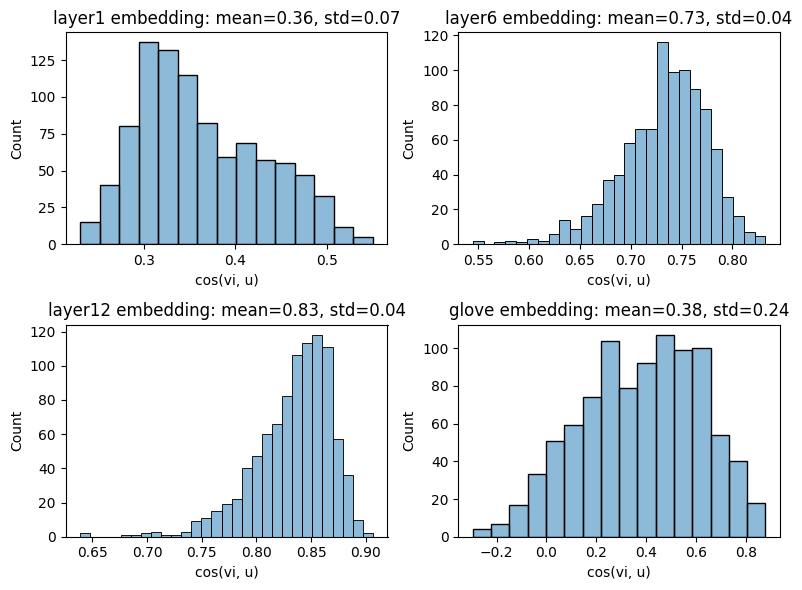

layer1:
A1: 0.0006150250108469999
EVR: [0.02723983 0.02162664 0.01605645 0.01518885 0.01339539 0.01266682
 0.01146093 0.01080315 0.01059406 0.01014419]
Cumulative variance: 0.15

layer6:
A1: -0.0008605728387659175
EVR: [0.04767747 0.02970711 0.02823488 0.01920526 0.01810175 0.01788278
 0.01575052 0.01501913 0.01383338 0.0124143 ]
Cumulative variance: 0.22

layer12:
A1: -0.000767795137081742
EVR: [0.07677786 0.02964835 0.0254009  0.02291043 0.01930149 0.01642735
 0.01617939 0.01538762 0.01433548 0.01386017]
Cumulative variance: 0.25

glove:
A1: -0.0005126314054193831
EVR: [0.13919092 0.05840788 0.05242213 0.04461478 0.04104496 0.03539921
 0.03473194 0.03304889 0.03048359 0.02821235]
Cumulative variance: 0.50



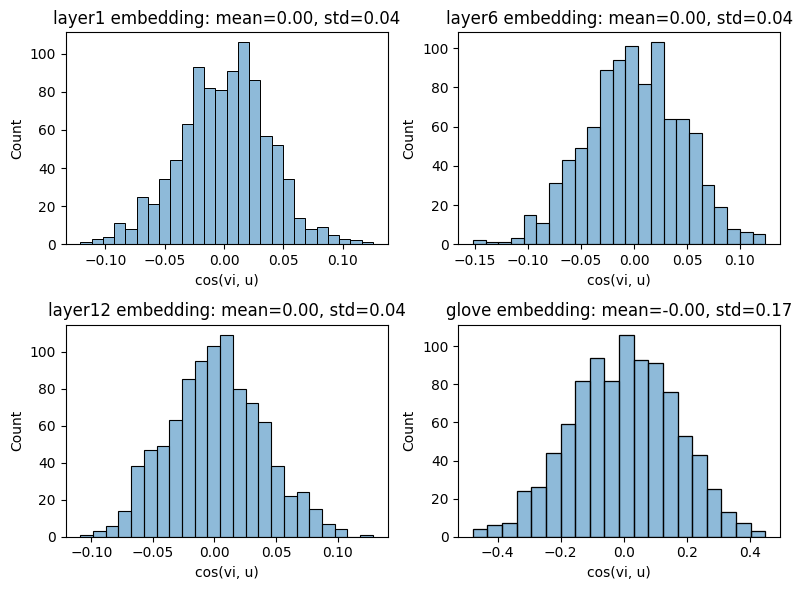

layer1:
A1: 0.0006150250108469984
EVR: [0.03893125 0.01918018 0.01628751 0.01369763 0.01228111 0.01159335
 0.01130752 0.01035307 0.00959504 0.00939079]
Cumulative variance: 0.15

layer6:
A1: -0.0008605728387659185
EVR: [0.0543377  0.03005289 0.02815108 0.01940581 0.01887278 0.01786375
 0.0159848  0.01461724 0.0139606  0.01217527]
Cumulative variance: 0.23

layer12:
A1: -0.0007677951370817413
EVR: [0.07211472 0.03104132 0.02642245 0.02296489 0.01944024 0.01673534
 0.01596284 0.01577847 0.01416021 0.01398946]
Cumulative variance: 0.25

glove:
A1: -0.0005126314054193821
EVR: [0.14965091 0.06120262 0.05520123 0.0458484  0.04397147 0.03620012
 0.03399403 0.0329633  0.0301951  0.02780105]
Cumulative variance: 0.52



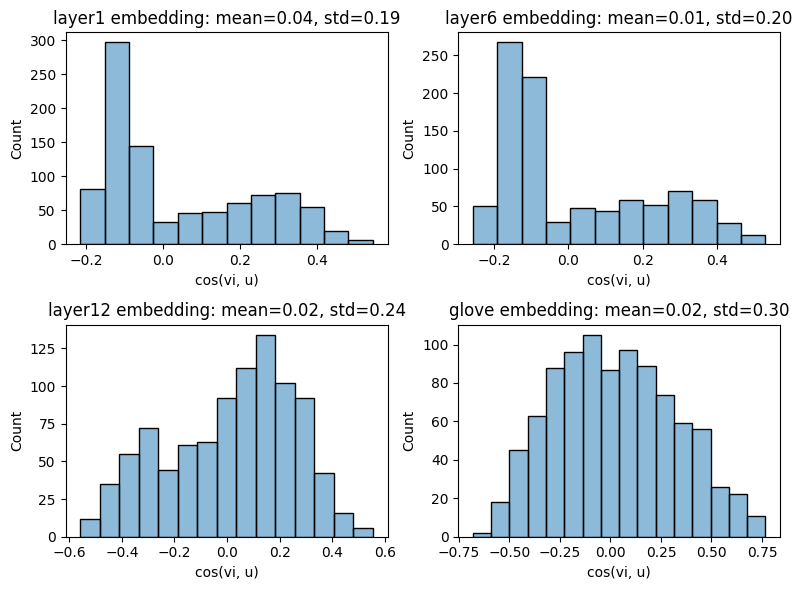

layer1:
A1: 0.13408724234764252
EVR: [0.02223224 0.01650635 0.01561401 0.01377059 0.013021   0.01178455
 0.01110342 0.01088451 0.0104384  0.01027787]
Cumulative variance: 0.14

layer6:
A1: 0.5416237152683627
EVR: [0.03119438 0.02964845 0.02016684 0.01900841 0.01877889 0.01653968
 0.01577316 0.01452566 0.01305457 0.01273158]
Cumulative variance: 0.19

layer12:
A1: 0.709989605065436
EVR: [0.032114   0.02751332 0.02481573 0.02090687 0.01779444 0.01752868
 0.01668853 0.01553091 0.0150232  0.01437362]
Cumulative variance: 0.20

glove:
A1: 0.12131361694621598
EVR: [0.06785231 0.06089867 0.05182889 0.04768184 0.04112319 0.04034802
 0.03839282 0.03541271 0.03277423 0.03074072]
Cumulative variance: 0.45



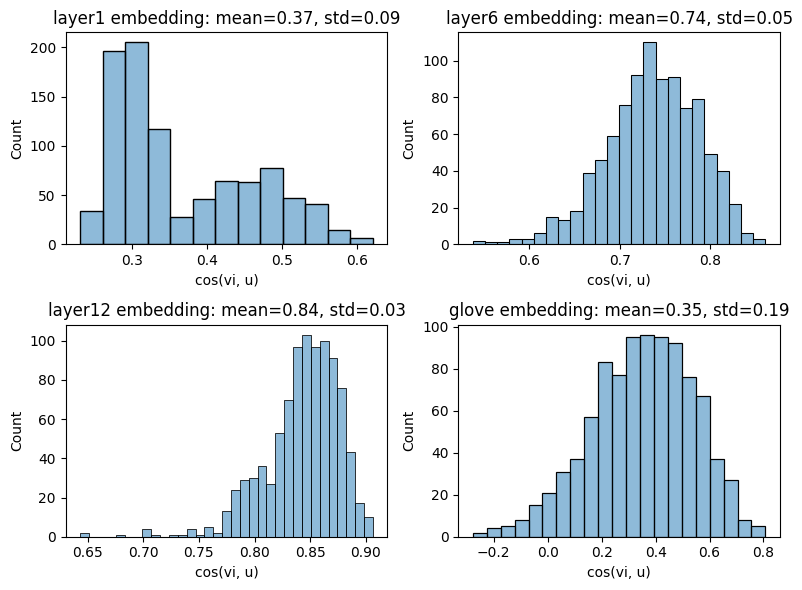

layer1:
A1: 0.13580947997508627
EVR: [0.01688176 0.01596917 0.01408528 0.01331849 0.01205207 0.01136316
 0.01114934 0.010679   0.01053593 0.00987286]
Cumulative variance: 0.13

layer6:
A1: 0.5388820919795144
EVR: [0.03060309 0.02081619 0.01962051 0.0193836  0.0170721  0.01628169
 0.01499453 0.01346814 0.01316484 0.01236936]
Cumulative variance: 0.18

layer12:
A1: 0.7158378630305934
EVR: [0.0284262  0.0256391  0.02160062 0.01838661 0.0181087  0.01724171
 0.0160555  0.01552581 0.01484627 0.01466417]
Cumulative variance: 0.19

glove:
A1: 0.1295141035607733
EVR: [0.06533157 0.05560158 0.05115266 0.0441166  0.04328501 0.04118749
 0.03799045 0.03515991 0.03297838 0.03214477]
Cumulative variance: 0.44



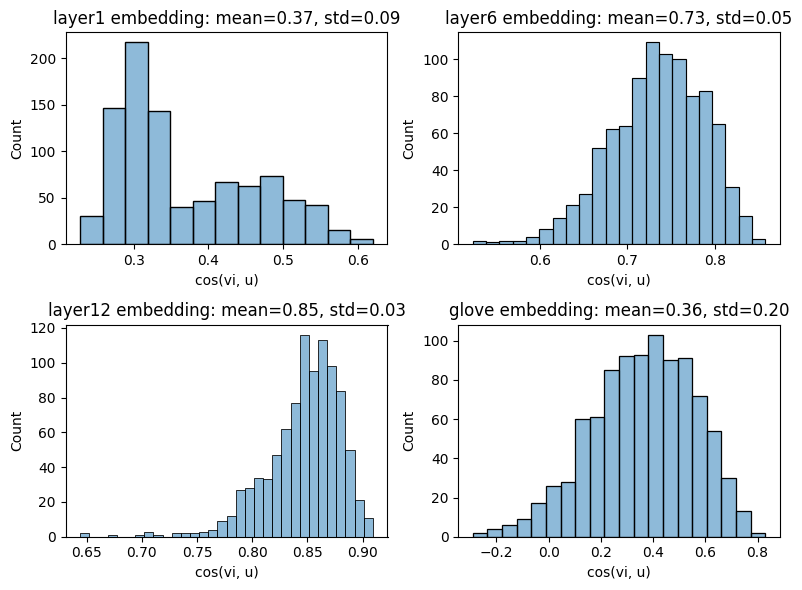

layer1:
A1: 0.14047861583664079
EVR: [0.01397461 0.01264793 0.0119262  0.01171453 0.01116265 0.01108382
 0.01037329 0.0101722  0.00969531 0.00927512]
Cumulative variance: 0.11

layer6:
A1: 0.550495419686095
EVR: [0.02086583 0.01837756 0.01752643 0.01614272 0.01450708 0.01418118
 0.01332332 0.01259366 0.01222647 0.01193094]
Cumulative variance: 0.15

layer12:
A1: 0.728386259290454
EVR: [0.01989199 0.01959372 0.01865457 0.01736765 0.01680079 0.01607543
 0.01585905 0.01565367 0.0142805  0.01360563]
Cumulative variance: 0.17

glove:
A1: 0.09043771747653523
EVR: [0.05328644 0.052282   0.0497485  0.04588695 0.04246806 0.03983309
 0.03882621 0.03761105 0.03563088 0.03399551]
Cumulative variance: 0.43



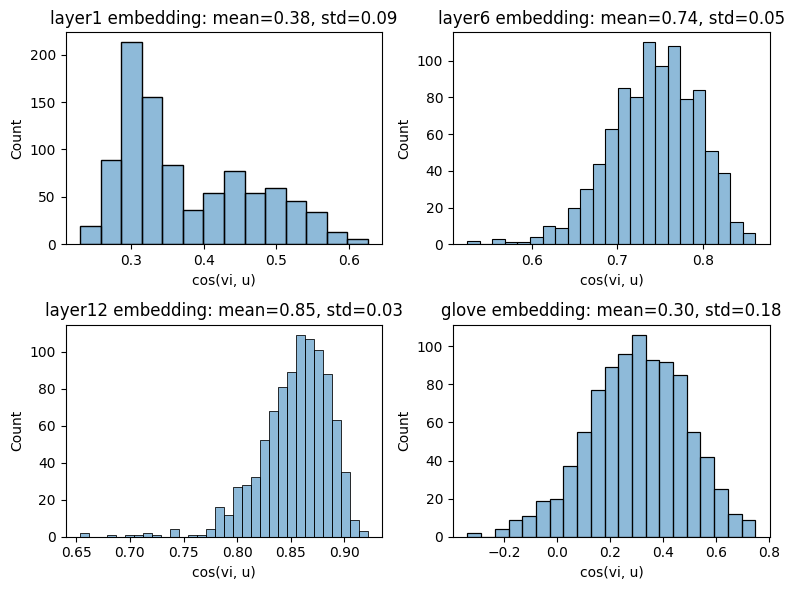

In [8]:
def load_embeddings(path):
    with open (path, "r") as f:
        emb_dict = json.load(f)
        return emb_dict


def convert_to_mat(emb_dict):
    word_list = list(emb_dict.keys())
    wemb_mat = np.array(list(emb_dict.values()))
    return word_list, wemb_mat


def pairwise_cos(wemb_mat, mean=None):
    similarity = cosine_similarity(wemb_mat)
    pairwise_cos = similarity[np.triu_indices(len(wemb_mat), k=1)]
    # returns [0.1, 0.02, ....] with k=1 to exclude diagonal values
    if mean:
        return pairwise_cos.mean()
    return pairwise_cos


def cos_to_mean(wemb_mat):
    u = np.mean(wemb_mat, axis=0)
    u = u.reshape(1, -1)
    similarity = cosine_similarity(wemb_mat, u)
    mean = similarity.mean()
    std = np.std(similarity)
    return mean, std, similarity


def pca_dominance(wemb_mat, k=10):
    pca = PCA(n_components=k)
    pca.fit(wemb_mat)
    evr = pca.explained_variance_ratio_
    cum_var = np.cumsum(evr)[-1]
    return evr, cum_var


def mean_centering(wemb_mat, norm=None):
    mean_cent = wemb_mat - np.mean(wemb_mat, axis=0)
    if norm:
        return mean_cent / np.linalg.norm(mean_cent, 
                                            axis=1,
                                            keepdims=True)
    return mean_cent


def remove_top_m(wemb_mat, m):
    pca = PCA(n_components=m)
    pca.fit(wemb_mat)

    #AI answered
    projection = wemb_mat @ pca.components_.T @ pca.components_
    return wemb_mat - projection


def compute_metrics(wemb_mat):
    A1 = pairwise_cos(wemb_mat, mean=True)
    mean, std, similarity = cos_to_mean(wemb_mat)
    evr, cum_var = pca_dominance(wemb_mat, k=10)
    return {"A1": A1, 
            "mean": mean, 
            "std": std, 
            "similarity": similarity,
            "EVR": evr,
            "cum_var": cum_var}


def get_results(transfo_fn=None):
    saved_embs = ["layer1", "layer6", "layer12", "glove"]
    res = {}
    for emb in saved_embs:
        emb_dict = load_embeddings(f"/home/onyxia/work/embeddings_{emb}.json")
        _, wemb_mat = convert_to_mat(emb_dict)
        
        if transfo_fn:
            wemb_mat = transfo_fn(wemb_mat)
        
        metrics = compute_metrics(wemb_mat)
        res[emb] = metrics
        print(f"{emb}:\nA1: {metrics["A1"]}\nEVR: {metrics["EVR"]}")
        print(f"Cumulative variance: {metrics["cum_var"]:.2f}\n")

    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.flatten()
    for ax, emb in zip(axes, saved_embs):
        sns.histplot(res[emb]["similarity"], ax=ax)
        ax.set_title(f"{emb} embedding: mean={res[emb]["mean"]:.2f}, std={res[emb]["std"]:.2f}")
        ax.set_xlabel("cos(vi, u)")
        ax.get_legend().remove()
    plt.tight_layout()
    plt.show()

# lambda mat not from me either, I looked at a way to group 
# results + plot of each layer by matrice transformation

get_results()
get_results(transfo_fn=mean_centering)
get_results(transfo_fn=lambda mat: mean_centering(mat, norm=True))
get_results(transfo_fn=lambda mat: remove_top_m(mat, m=1))
get_results(transfo_fn=lambda mat: remove_top_m(mat, m=2))
get_results(transfo_fn=lambda mat: remove_top_m(mat, m=5))

In [8]:
df = pd.read_csv("/home/onyxia/work/morph_families.tsv", 
                sep="\t", 
                names=["lemma", "forms", "fam", "transf"])


Offset consistency
layer1 [raw]: pairs=25 | mean=0.291 | CI=[0.281, 0.302]
layer1 [centered]: pairs=25 | mean=0.291 | CI=[0.281, 0.303]
layer6 [raw]: pairs=25 | mean=0.307 | CI=[0.294, 0.320]
layer6 [centered]: pairs=25 | mean=0.307 | CI=[0.294, 0.320]
layer12 [raw]: pairs=25 | mean=0.411 | CI=[0.396, 0.425]
layer12 [centered]: pairs=25 | mean=0.411 | CI=[0.396, 0.425]
glove [raw]: pairs=25 | mean=0.343 | CI=[0.323, 0.363]
glove [centered]: pairs=25 | mean=0.343 | CI=[0.322, 0.363]

Intra / inter family distances
layer1: intra=0.630 | inter=0.126 | d=4.38 [3.92, 4.92] | p=3.830e-91
layer6: intra=0.824 | inter=0.564 | d=3.51 [3.19, 3.88] | p=6.291e-88
layer12: intra=0.872 | inter=0.724 | d=3.49 [3.18, 3.88] | p=2.423e-87
glove: intra=0.747 | inter=0.417 | d=2.14 [1.94, 2.36] | p=6.541e-71
tr_layer1: intra=0.586 | inter=0.026 | d=4.36 [3.89, 4.94] | p=1.579e-89
tr_layer6: intra=0.621 | inter=0.057 | d=4.22 [3.83, 4.64] | p=1.097e-91
tr_layer12: intra=0.561 | inter=0.051 | d=4.37 [3.95, 4

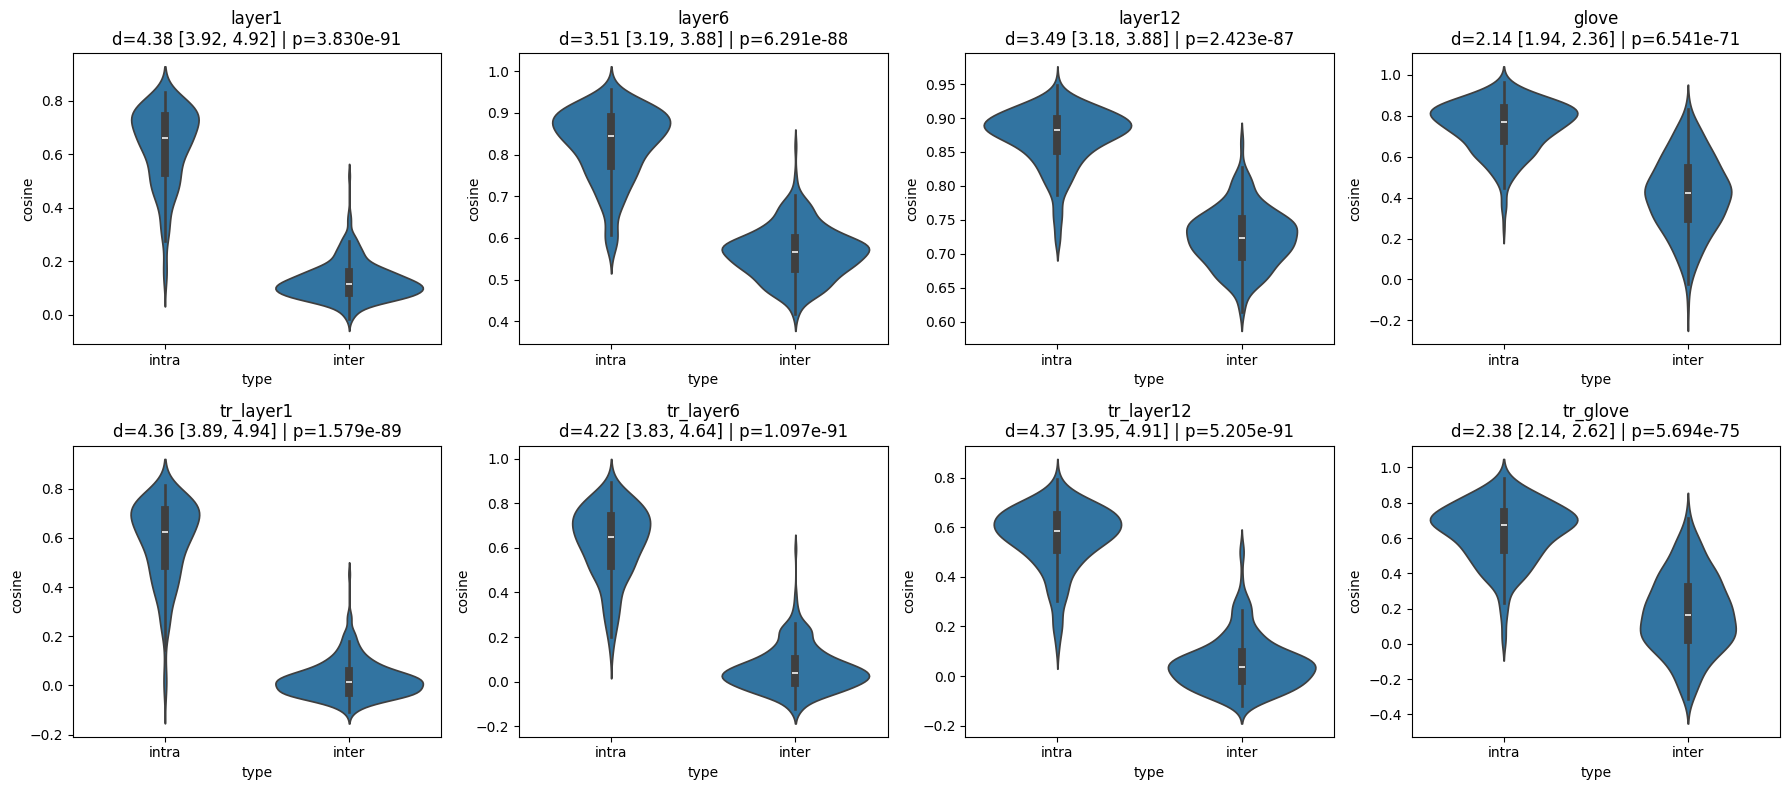

In [10]:
def get_vecs(forms, emb_dict):
    return np.array([emb_dict[form] for form in forms.split(",")])
   

def intra_family_cos(df, emb):
    res = []
    for wemb in df[emb]:
        res.extend(pairwise_cos(wemb))
    return res


def inter_family_cos(df, emb, n):
    res = []
    random.seed(42)
    fam_record = []
    for fam_idx, forms in enumerate(df["forms"].str.split(",")):
        for form_idx in range(len(forms)):
            fam_record.append((fam_idx, form_idx))
    while len(res) < n:
        (f1, w1), (f2, w2) = random.sample(fam_record, 2)
        if f1 == f2:
            continue
        # gets the corresponding wemb, reshape necessary with 
        # cos_sim of skleanr
        v1 = df[emb][f1][w1].reshape(1, -1)
        v2 = df[emb][f2][w2].reshape(1, -1)
        res.append(cosine_similarity(v1, v2)[0][0])
    return res


def get_offset(df, emb_dict, suffix):
    offsets = []
    verb_df = df[df["transf"].str.contains("verb")]
    
    for _, row in verb_df.iterrows():
        forms = [f.strip() for f in row["forms"].split(",")]
        root = row["lemma"]
        target = next((f for f in forms if f.endswith(suffix) and f != root), None)
        
        if target:
            offset = np.array(emb_dict[target]) - np.array(emb_dict[root])
            offsets.append(offset)
    
    return offsets
    

def offset_consistency(offsets):
    similarity = []
    for o1, o2 in combinations(offsets, 2):
        v1, v2 = o1.reshape(1, -1), o2.reshape(1, -1)
        similarity.append(cosine_similarity(v1, v2)[0][0])
    
    sims = np.array(similarity)
    mean_sim = np.mean(sims)
    ci = bootstrap((sims,), np.mean)
    return mean_sim, ci.confidence_interval.low, ci.confidence_interval.high


# I put in the df the embeddings of all forms per family
# Update: and the wemb after transformation
print("Offset consistency")
saved_embs = ["layer1", "layer6", "layer12", "glove"]
for emb in saved_embs:
    emb_dict = load_embeddings(f"/home/onyxia/work/embeddings_{emb}.json")
    df[emb] = df["forms"].apply(get_vecs, emb_dict=emb_dict)

    word_list, wemb_mat = convert_to_mat(emb_dict)
    emb_dict_tr = dict(zip(word_list, mean_centering(wemb_mat)))
    df[f"tr_{emb}"] = df["forms"].apply(get_vecs, emb_dict=emb_dict_tr)

    # (ii) offset consistency
    offsets = get_offset(df, emb_dict, suffix="ed")
    mean_sim, ci_low, ci_high = offset_consistency(offsets)
    print(f"{emb} [raw]: pairs={len(offsets)} | mean={mean_sim:.3f} | CI=[{ci_low:.3f}, {ci_high:.3f}]")

    offsets_tr = get_offset(df, emb_dict_tr, suffix="ed")
    mean_sim, ci_low, ci_high = offset_consistency(offsets_tr)
    print(f"{emb} [centered]: pairs={len(offsets_tr)} | mean={mean_sim:.3f} | CI=[{ci_low:.3f}, {ci_high:.3f}]") 


# AI part below for other metrics / plot I gave up on spending time
def cohen_d(a, b):
    pooled_std = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std


def bootstrap_ci(a, b, n_bootstrap=1000, alpha=0.05):
    ds = []
    for _ in range(n_bootstrap):
        s_a = np.random.choice(a, size=len(a), replace=True)
        s_b = np.random.choice(b, size=len(b), replace=True)
        ds.append(cohen_d(s_a, s_b))
    return np.percentile(ds, [100*alpha/2, 100*(1-alpha/2)])


def plot_intra_inter(results, all_versions):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for ax, version in zip(axes, all_versions):
        intra = results[version]["intra"]
        inter = results[version]["inter"]
        data = pd.DataFrame({
            "cosine": intra + inter,
            "type": ["intra"] * len(intra) + ["inter"] * len(inter)
        })
        sns.violinplot(data=data, x="type", y="cosine", ax=ax)
        d, ci, p = results[version]["cohen_d"], results[version]["ci"], results[version]["p"]
        ax.set_title(f"{version}\nd={d:.2f} [{ci[0]:.2f}, {ci[1]:.2f}] | p={p:.3e}")
    plt.tight_layout()
    plt.show()


all_versions = saved_embs + [f"tr_{emb}" for emb in saved_embs]
results = {}

print("\nIntra / inter family distances")
for version in all_versions:
    intra = intra_family_cos(df, version)
    inter = inter_family_cos(df, version, n=len(intra))

    stat, p = mannwhitneyu(intra, inter, alternative="greater")
    d = cohen_d(intra, inter)
    ci = bootstrap_ci(intra, inter)

    results[version] = {"intra": intra, "inter": inter, "cohen_d": d, "ci": ci, "p": p}
    print(f"{version}: intra={np.mean(intra):.3f} | inter={np.mean(inter):.3f} | d={d:.2f} [{ci[0]:.2f}, {ci[1]:.2f}] | p={p:.3e}")

plot_intra_inter(results, all_versions)
# //end AI

In [6]:
with open("/home/onyxia/work/filtered_synonyms.json") as f:
    filtered_synonyms = json.load(f)

with open("/home/onyxia/work/filtered_antonyms.json") as f:
    filtered_antonyms = json.load(f)

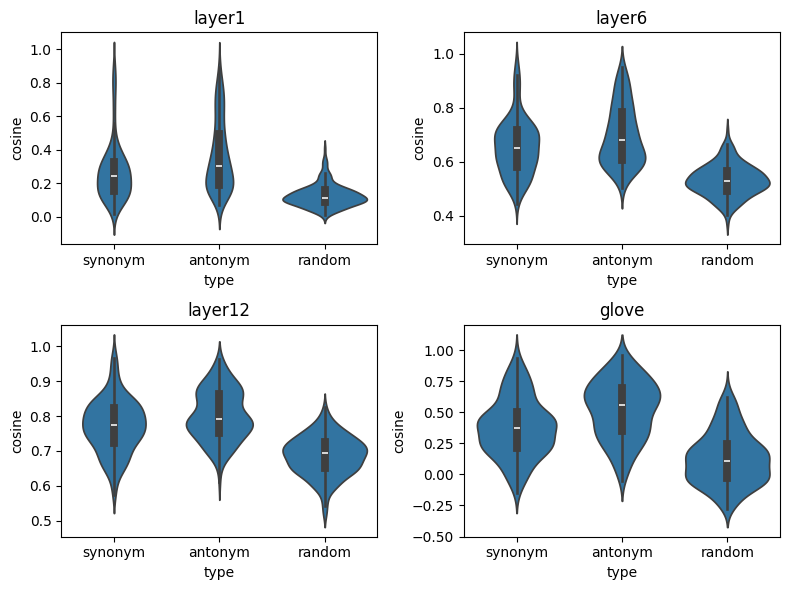

In [9]:
def pair_cos(pairs, emb_dict):
    scores = []
    for l1, l2 in pairs:
        if l1 in emb_dict and l2 in emb_dict:
            v1 = np.array(emb_dict[l1]).reshape(1, -1)
            v2 = np.array(emb_dict[l2]).reshape(1, -1)
            scores.append(cosine_similarity(v1, v2)[0][0])
    return scores


def random_pairs(emb_dict):
    random.seed(42)
    words = list(emb_dict.keys())
    pairs = []
    # 200 since we have 200 pair of each syn / ant
    while len(pairs) < 200:
        l1, l2 = random.sample(words, 2)
        pairs.append((l1, l2))
    return pairs


# AI plot
saved_embs = ["layer1", "layer6", "layer12", "glove"]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for ax, emb in zip(axes, saved_embs):
    emb_dict = load_embeddings(f"/home/onyxia/work/embeddings_{emb}.json")
    
    syn_scores  = pair_cos(filtered_synonyms, emb_dict)
    ant_scores  = pair_cos(filtered_antonyms, emb_dict)
    rand_scores = pair_cos(random_pairs(emb_dict), emb_dict)
    
    data = pd.DataFrame({
        "cosine": syn_scores + ant_scores + rand_scores,
        "type": ["synonym"] * len(syn_scores) + ["antonym"] * len(ant_scores) + ["random"] * len(rand_scores)
    })
    sns.violinplot(data=data, x="type", y="cosine", ax=ax)
    ax.set_title(emb)

plt.tight_layout()
plt.show()

In [13]:
def knn(word, emb_dict, k=10):
    words = list(emb_dict.keys())
    wembs = np.array(list(emb_dict.values()))

    nn = NearestNeighbors(n_neighbors=k+1, metric="cosine")
    nn.fit(wembs)

    i = words.index(word)
    distances, idx = nn.kneighbors(wembs[i].reshape(1, -1))

    neighbour_idx = idx[0][1:]
    return [words[i] for i in neighbour_idx]


def antonym_neighbours(target_words, emb_dict, filtered_antonyms):
    ant_dict = {w1: w2 for w1, w2 in filtered_antonyms}
    ant_dict.update({w2: w1 for w1, w2 in filtered_antonyms})

    count = 0
    total = 0
    for word in target_words:
        if word not in emb_dict:
            continue
        ant = ant_dict.get(word)
        if not ant or ant not in emb_dict:
            continue
        neighbours = knn(word, emb_dict, k=10)
        if ant in neighbours:
            count += 1
        total += 1
    
    return count, total, count/total


random.seed(42)
target_words = random.sample(list(emb_dict.keys()), 50)

saved_embs = ["layer1", "layer6", "layer12", "glove"]
for emb in saved_embs:
    emb_dict = load_embeddings(f"/home/onyxia/work/embeddings_{emb}.json")
    
    count, total, ratio = antonym_neighbours(target_words, emb_dict, filtered_antonyms)
    print(f"{emb} embedding: {ratio:.2f} ({count} / {total})")

    word_list, wemb_mat = convert_to_mat(emb_dict)
    emb_dict_tr = dict(zip(word_list, mean_centering(wemb_mat)))
    count, total, rate = antonym_neighbours(target_words, emb_dict_tr, filtered_antonyms)
    print(f"{emb} mean centered: {ratio:.2f} ({count} / {total})")

layer1 embedding: 0.44 (8 / 18)
layer1 mean centered: 0.44 (10 / 18)
layer6 embedding: 0.50 (9 / 18)
layer6 mean centered: 0.50 (9 / 18)
layer12 embedding: 0.56 (10 / 18)
layer12 mean centered: 0.56 (10 / 18)
glove embedding: 0.50 (9 / 18)
glove mean centered: 0.50 (10 / 18)
